In [82]:
%pip install numpy
%pip install scipy
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn

In [87]:
from scipy.io import arff
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix
from scipy.stats import mode
import pandas as pd

# Load the ARFF dataset
data = arff.loadarff('column_diagnosis.arff')
df = pd.DataFrame(data[0])

# Separate features and labels
x = df.drop('class', axis=1)

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
x_normalized = scaler.fit_transform(x)

# Define the range of k values to try asked
k_values = [2, 3, 4, 5]


silhouette_scores = []
purity_scores = []

# Apply k-means clustering
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    cluster_labels = kmeans.fit_predict(x_normalized)
    
    # Calculate silhouette score
    silhouette = silhouette_score(x_normalized, cluster_labels)
    silhouette_scores.append(silhouette)
    
    # Calculate purity score
    
    cluster_labels = cluster_labels.astype(str)  # Convert 'cluster_labels' to string for consistency
    conf_matrix = confusion_matrix(df['class'].apply(lambda x: x.decode('utf-8')), cluster_labels)
    purity = np.sum(np.amax(conf_matrix, axis=0)) / np.sum(conf_matrix)
    purity_scores.append(purity)


for k, silhouette, purity in zip(k_values, silhouette_scores, purity_scores):
    print(f'K = {k}, Silhouette Score = {silhouette:.4f}, Purity Score = {purity:.4f}')


/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super

K = 2, Silhouette Score = 0.3604, Purity Score = 0.6323
K = 3, Silhouette Score = 0.2958, Purity Score = 0.6677
K = 4, Silhouette Score = 0.2744, Purity Score = 0.6613
K = 5, Silhouette Score = 0.2382, Purity Score = 0.6774


In [88]:
from sklearn.decomposition import PCA
import numpy as np

# Apply PCA on the normalized data
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_normalized)

# Variability explained by the top two principal components
explained_var_ratio = pca.explained_variance_ratio_
explained_var = explained_var_ratio * 100 

# Total Explained Variability
explained_total_var = explained_var[0] + explained_var[1]

print(f"Explained Variability by PC1: {explained_var[0]:.2f}%")
print(f"Explained Variability by PC2: {explained_var[1]:.2f}%")
print(f"Total Explained Variability: {explained_total_var:.2f}%")

# Sort input variables by relevance for each component
component_weights = pca.components_

# For PC1
pc1_weights = component_weights[0]
sorted_indices_pc1 = np.argsort(np.abs(pc1_weights))[::-1]
sorted_variables_pc1 = x.columns[sorted_indices_pc1]

# For PC2
pc2_weights = component_weights[1]
sorted_indices_pc2 = np.argsort(np.abs(pc2_weights))[::-1]
sorted_variables_pc2 = x.columns[sorted_indices_pc2]

print(f"\nTop variables for PC1:")
for var in sorted_variables_pc1:
    print(var)

print(f"\nTop variables for PC2:")
for var in sorted_variables_pc2:
    print(var)


Explained Variability by PC1: 56.18%
Explained Variability by PC2: 20.96%
Total Explained Variability: 77.14%

Top variables for PC1:
pelvic_incidence
lumbar_lordosis_angle
pelvic_tilt
sacral_slope
degree_spondylolisthesis
pelvic_radius

Top variables for PC2:
pelvic_tilt
pelvic_radius
sacral_slope
pelvic_incidence
lumbar_lordosis_angle
degree_spondylolisthesis


/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


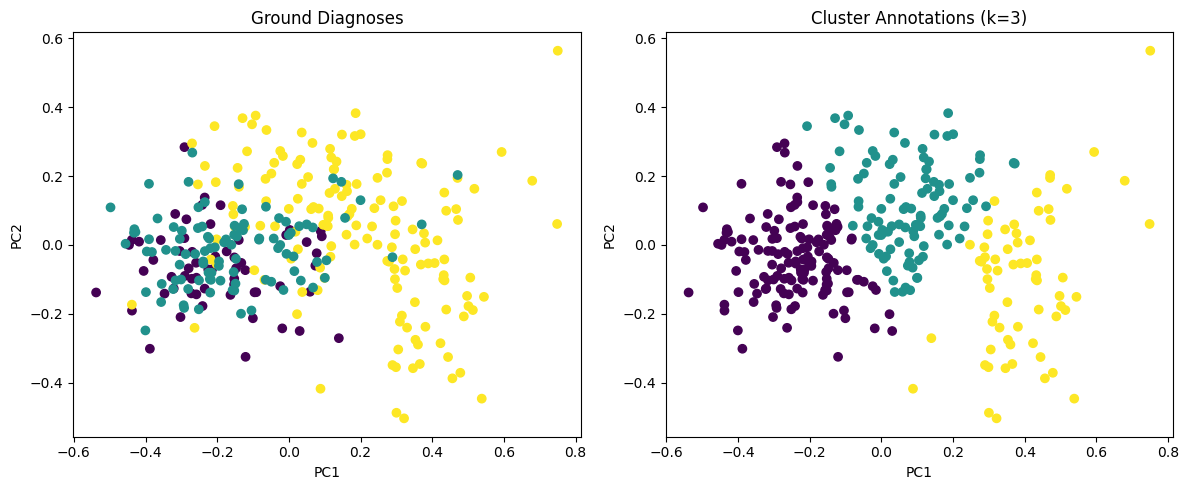

In [89]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder



# Ground diagnoses
class_labels = df['class'].apply(lambda x: x.decode('utf-8'))

# K-means clustering with k=3
kmeans = KMeans(n_clusters=3, random_state=0)
cluster_labels = kmeans.fit_predict(x_normalized)

# Convert class labels to numerical values
label_encoder = LabelEncoder()
class_labels_encoded = label_encoder.fit_transform(class_labels)

# Visualize the data
plt.figure(figsize=(12, 5))

# Plot ground diagnoses
plt.subplot(1, 2, 1)
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=class_labels_encoded, cmap='viridis')
plt.title('Ground Diagnoses')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Plot cluster annotations
plt.subplot(1, 2, 2)
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=cluster_labels, cmap='viridis')
plt.title('Cluster Annotations (k=3)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.show()





In [90]:
'''
Disease Subtyping:

Thinking of clustering, like using a special tool (k-means clustering), to sort people based on their health and putting them into two groups.
In one group, most people might have a particular health issue (like 'Hernia'). In the other group, people don't have that issue.
This makes it easy to see the difference between the two groups. These groups are really helpful for giving specific treatments. For example, 
if one group has its own set of symptoms or needs special care, doctors can customize treatments just for them.

Monitoring Disease Progression:

Clustering also helps us keep an eye on how different groups of people (sorted by their health) change over time. When we use clustering on data collected
over a long period, we can see how the health of people in each group changes. This gives us clues about how diseases develop and can even help us spot
when things are getting worse. For instance, if we have data from different times, we can use clustering at each point to find groups that stay the same and ones 
that change. This info helps doctors plan treatments based on how the disease is moving within these specific groups.
'''


"\nDisease Subtyping:\n\nThinking of clustering, like using a special tool (k-means clustering), to sort people based on their health and putting them into two groups.\nIn one group, most people might have a particular health issue (like 'Hernia'). In the other group, people don't have that issue.\nThis makes it easy to see the difference between the two groups. These groups are really helpful for giving specific treatments. For example, \nif one group has its own set of symptoms or needs special care, doctors can customize treatments just for them.\n\nMonitoring Disease Progression:\n\nClustering also helps us keep an eye on how different groups of people (sorted by their health) change over time. When we use clustering on data collected\nover a long period, we can see how the health of people in each group changes. This gives us clues about how diseases develop and can even help us spot\nwhen things are getting worse. For instance, if we have data from different times, we can use clu